In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../data/train_matrix.csv')

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from dataLoading import load_all_data
from dataPreprocessing import preprocess
from featureEngineering import engineer_features

def check_pca_necessity(df, feature_cols):
    """
    Evaluates whether PCA is necessary by computing the principal components
    and analyzing the cumulative explained variance.
    Returns boolean indicating if PCA is recommended, and the number of components needed.
    """
    print(f"\nEvaluating PCA on {len(feature_cols)} features...")
    
    # Drop NaNs just in case
    data_for_pca = df[feature_cols].copy().dropna()
    
    pca = PCA()
    pca.fit(data_for_pca)
    
    explained_var = pca.explained_variance_ratio_
    cum_explained_var = np.cumsum(explained_var)
    
    # Print variance details
    print("\nExplained Variance Ratio per Principal Component:")
    for i, var in enumerate(explained_var):
        print(f"PC{i+1}: {var:.4f} (Cumulative: {cum_explained_var[i]:.4f})")
    
    # Check how many components explain 90% variance
    components_90 = np.argmax(cum_explained_var >= 0.90) + 1
    
    print(f"\nNumber of components needed to explain 90% of variance: {components_90}")
    
    # Generate visualization
    os.makedirs('visualizations', exist_ok=True)
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(cum_explained_var) + 1), cum_explained_var, marker='o', linestyle='-', color='b')
    plt.axhline(y=0.90, color='r', linestyle='--', label='90% Threshold')
    plt.title('Cumulative Explained Variance by PCA Components')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.xticks(range(1, len(cum_explained_var) + 1))
    plt.legend()
    plt.grid(True)
    
    save_path = os.path.join('visualizations', 'pca_variance_analysis.png')
    plt.savefig(save_path)
    plt.close()
    
    print(f"Saved PCA scree plot to {save_path}")
    
    # Interpretation
    threshold_ratio = components_90 / len(feature_cols)
    print("\n--- PCA Recommendation ---")
    
    is_recommended = threshold_ratio < 0.7
    if is_recommended:
        print("Recommendation: PCA is recommended. A significant dimensionality reduction "
              "is possible while retaining 90% of the variance.")
    else:
        print("Recommendation: PCA is NOT strictly necessary for dimensionality reduction. "
              "You need most of the components to explain the variance, implying features are largely independent. "
              "Proceeding with original engineered features for clustering.")
              
    return is_recommended, components_90

def pca(user_features_df):
    print("\n--- Phase 3: PCA Evaluation ---")
    
    # Evaluate PCA on the available engineered customer features
    feature_cols = [col for col in user_features_df.columns if col != 'user_id']
    
    # Proceed with checking PCA necessity
    is_recommended, components_90 = check_pca_necessity(user_features_df, feature_cols)
    
    # If PCA is considered useful, perform reduction and save to CSV for optional downstream modeling
    if is_recommended:
        print(f"\nApplying PCA dimensionality reduction to {components_90} components...")
        
        # Fit and transform
        pca_model = PCA(n_components=components_90)
        reduced_features = pca_model.fit_transform(user_features_df[feature_cols].fillna(0))
        
        # Reconstruct as DataFrame with PC column names
        pca_cols = [f'PC{i+1}' for i in range(components_90)]
        reduced_df = pd.DataFrame(reduced_features, columns=pca_cols)
        
        # Append the user_id back for processing linkage
        reduced_df['user_id'] = user_features_df['user_id'].values
        
        # Reorder so user_id is first
        reduced_df = reduced_df[['user_id'] + pca_cols]
        
        # Save to memory/disk
        os.makedirs('data', exist_ok=True)
        reduced_path = os.path.join('data', 'user_features_pca_reduced.csv')
        reduced_df.to_csv(reduced_path, index=False)
        print(f"-> Successfully saved PCA-reduced dataset to '{reduced_path}'")
    
    # Return unchanged feature dataset for the standard clustering pipeline
    return user_features_df

if __name__ == "__main__":
    from dataVisualization import generate_visualizations
    
    # Load data when run as a standalone script
    orders, products, order_products, departments, aisles = load_all_data()
    
    # Run the preprocessing pipeline
    orders, products, order_products, departments, aisles = preprocess(orders, products, order_products, departments, aisles)
    
    # Feature Engineering
    user_features_df = engineer_features(orders, order_products)

    # PCA Check
    user_features_df = pca(user_features_df)

    # Data Visualization (Generates Market Visualizations on raw data)
    generate_visualizations(orders, products, order_products)


In [13]:
#Filter out non-behavioral identifiers (IDs, Names)
print("Isolating behavioral features...")
identifiers = ['user_id', 'order_id', 'product_id', 'aisle_id', 'department_id', 'product_name', 'department', 'aisle']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c not in identifiers]
X = df[feature_cols].copy().fillna(0)

Isolating behavioral features...


In [8]:
print("No of features:", len(feature_cols))

No of features: 42


In [14]:
print("Standardizing features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Standardizing features...


In [16]:
print("Fitting PCA...")
pca = PCA()
pca.fit(X_scaled)
variance_threshold=0.9

Fitting PCA...


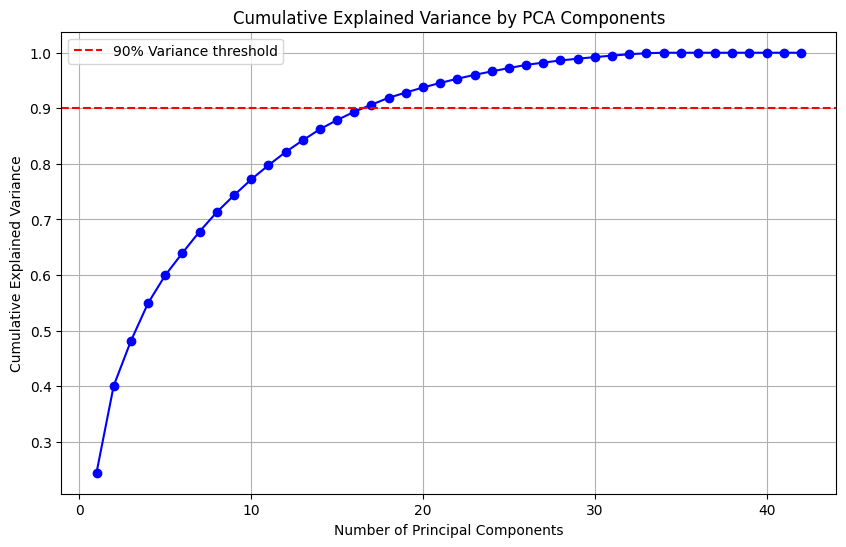

In [17]:
# Plot the Cumulative Explained Variance (Scree Plot)
cum_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_variance)+1), cum_variance, marker='o', linestyle='-', color='b')
plt.axhline(0.90, color='r', linestyle='--', label='90% Variance threshold')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
#Analyze Feature Loadings: What's driving the clusters?

loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(pca.n_components_)], index=feature_cols)
#Loadings tell us which raw customer behavior features contribute most to the variance
print("\n--- Features Driving Principal Component 1 (PC1) ---")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))
print("\n--- Features Driving Principal Component 2 (PC2) ---")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))



--- Features Driving Principal Component 1 (PC1) ---
user_total_orders       0.288438
order_number            0.288438
user_total_items        0.275540
user_reordered_items    0.269492
user_reorder_rate       0.256374
Name: PC1, dtype: float64

--- Features Driving Principal Component 2 (PC2) ---
product_users               0.280127
product_user_penetration    0.280127
product_orders              0.278327
product_reordered           0.272713
product_reorder_rate        0.257699
Name: PC2, dtype: float64


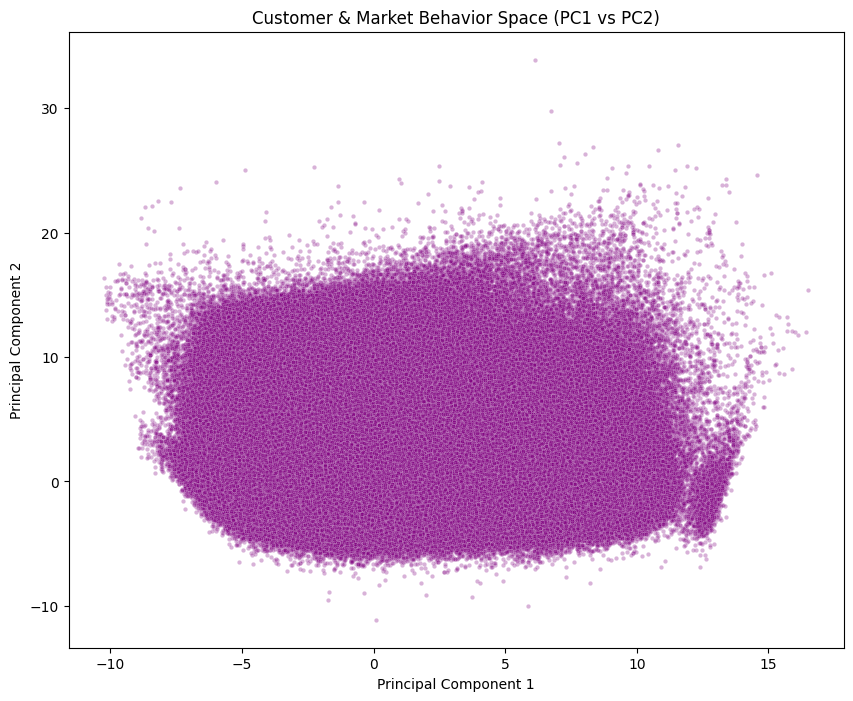

In [19]:
#Visualize the market in a 2D Feature Space
pca_2d = PCA(n_components=2)
reduced_2d = pca_2d.fit_transform(X_scaled)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=reduced_2d[:,0], y=reduced_2d[:,1], alpha=0.3, color='purple', s=10)
plt.title('Customer & Market Behavior Space (PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [20]:
components_needed = np.argmax(cum_variance >= variance_threshold) + 1
print(f"Total original features: {X_scaled.shape[1]}")
print(f"To retain {int(variance_threshold * 100)}% of the market variance, you only need: {components_needed} features.")
print(f"Dimensionality reduction achieved: {((X_scaled.shape[1] - components_needed) / X_scaled.shape[1]) * 100:.1f}%")

Total original features: 42
To retain 90% of the market variance, you only need: 17 features.
Dimensionality reduction achieved: 59.5%


In [21]:
optimal_pca = PCA(n_components=components_needed)
print(f"Applying PCA transformation to reduce down to {components_needed} dimensions...")
reduced_features_array = optimal_pca.fit_transform(X_scaled)

Applying PCA transformation to reduce down to 17 dimensions...


In [22]:
#Restructure it back into a Pandas DataFrame for easy handling
pca_columns = [f'PC{i+1}' for i in range(components_needed)]
df_pca_reduced = pd.DataFrame(reduced_features_array, columns=pca_columns)



In [23]:
# cluster belongs to which customer later when you generate insights.
df_pca_reduced['user_id'] = df['user_id'].values 
if 'order_id' in df.columns:
    df_pca_reduced['order_id'] = df['order_id'].values
# Reorder so IDs are nicely at the front
cols_to_front = [col for col in ['user_id', 'order_id'] if col in df_pca_reduced.columns]
df_pca_reduced = df_pca_reduced[cols_to_front + pca_columns]
display(df_pca_reduced.head())

,user_id,order_id,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17
0,1,1187899,-2.762436,7.563357,-5.508384,-2.921698,1.136452,-2.007610,-1.069454,-0.188487,0.580443,1.375696,-0.079036,-1.788486,2.975127,0.606689,-2.242079,-0.097307,-1.061677
1,1,1187899,-2.568507,5.855256,-5.996348,-2.852367,0.975662,-2.596018,-0.184502,0.367723,1.015493,1.318682,0.091010,-1.779792,2.778796,0.822589,-1.745148,-0.127097,-0.836857
2,1,1187899,-2.432081,-0.356866,0.310681,-1.469742,0.242920,-2.210299,-0.374307,-1.610695,0.980054,1.511208,2.289928,-1.683495,0.330618,-0.118694,-0.617130,-1.249504,0.477373
3,1,1187899,-2.641669,6.264898,-5.677899,-3.065701,1.340836,-2.689625,-0.063182,0.214644,0.841663,1.514559,-0.091864,-1.747709,0.321633,-0.786705,-3.363032,0.340543,-0.543602
4,1,1187899,-1.789232,1.940156,-2.560119,-1.289048,0.003265,-2.321359,-0.040475,-0.911408,2.312929,0.957506,2.041052,-1.713790,2.271676,1.556878,0.053850,-0.384858,-0.827869


In [24]:
save_path = '../data/pca_reduced_cluster_input.csv'
df_pca_reduced.to_csv(save_path, index=False)
print(f"\nSuccessfully saved PCA-reduced dataset to {save_path}")


Successfully saved PCA-reduced dataset to ../data/pca_reduced_cluster_input.csv
